# Q10.
```{admonition}
:class: note
This question should be answered with the `Carseats` data set.

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP.models import summarize

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

In [ ]:
carseats = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Carseats.csv')

In [21]:
carseats[carseats.isna().any(axis=1)]

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US


In [22]:
carseats.sample(3)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
231,8.09,132,69,0,123,122,Medium,27,11,No,No
304,11.93,123,98,12,408,134,Good,29,10,Yes,Yes
79,9.14,134,67,0,286,90,Bad,41,13,Yes,No


In [117]:
carseats.dtypes

Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object

## (a)
```{admonition}
:class: note
Fit a multiple regression model to predict `Sales` using `Price`, `Urban`, and `US`.

In [116]:
X = carseats[['Price','Urban','US']].copy()
X[['Urban','US']] = (X[['Urban','US']] == 'Yes').astype('int64')
X = sm.add_constant(X)
y = carseats['Sales'].copy()
model = sm.OLS(y,X).fit()
summarize(model)

,coef,std err,t,P>|t|
const,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban,-0.0219,0.272,-0.081,0.936
US,1.2006,0.259,4.635,0.000


## (b)
```{admonition}
:class: note
Provide an interpretation of each coefficient in the model.

- We expect a baseline of 1304 units sold.
- Increasing the price by 1 leads to a decrease in sales by approximately 55 units.
- If sales are in an urban environment, we expect 22 less units sold.
- If sales are in the US, we expect 1201 more units sold.

## (c)
```{admonition}
:class: note
Write out the model in equation form.

In [112]:
b0, *bi = model.params
vars = ['price','is_urban','is_US']
model_str = f'The model is sales = {b0:.4f}'+''.join(f'{coef:+.4f}*{var}' for coef,var in zip(bi,vars))
print(model_str)
#print(f'The model is sales = {b0:.2f}{b1:+.2f}price{b2:+.2f}is_urban{b3:+.2f}is_US.')

The model is sales = 13.0435-0.0545*price-0.0219*is_urban+1.2006*is_US


## (d)
```{admonition}
:class: note
For which of the predictors can you reject the null hypothesis $H_{0}: \beta_{j} = 0$?

The $p$-value for `Price` and `US` is below $0.05$, so the null hypothesis may be rejected.

## (e)
```{admonition}
:class: note
On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

In [115]:
X2 = X.drop(columns = ['Urban']).copy()
model2 = sm.OLS(y,X2).fit()
summarize(model2)

,coef,std err,t,P>|t|
const,13.0308,0.631,20.652,0.0
Price,-0.0545,0.005,-10.416,0.0
US,1.1996,0.258,4.641,0.0


## (f)
```{admonition}
:class: note
How well do the models in (a) and (e) fit the data?

In [136]:
model1_rmse = np.sqrt(model.mse_model)
model1_r2 = model.rsquared

model2_rmse = np.sqrt(model2.mse_model)
model2_r2 = model2.rsquared

In [140]:
print(f'The larger model has RMSE of {model1_rmse:.2f} and R^2 of {model1_r2:.2f}')
print(f'The smaller model has RMSE of {model2_rmse:.2f} and R^2 of {model2_r2:.2f}')

The larger model has RMSE of 15.93 and R^2 of 0.24
The smaller model has RMSE of 19.51 and R^2 of 0.24


## (g)
```{admonition}
:class: note
Using the model from (e), obtain 95% confidence intervals for the coefficients.

In [163]:
CI_df = model2.conf_int(alpha = 0.05)
for row in CI_df.index:
    L = CI_df.loc[row][0]
    R = CI_df.loc[row][1]
    print(f'Confidence interval for {row}: ({L:.2f},{R:.2f})')

Confidence interval for const: (11.79,14.27)
Confidence interval for Price: (-0.06,-0.04)
Confidence interval for US: (0.69,1.71)


## (h)
```{admonition}
:class: note
Is there evidence of outliers or high leverage observations in the model from (e)?

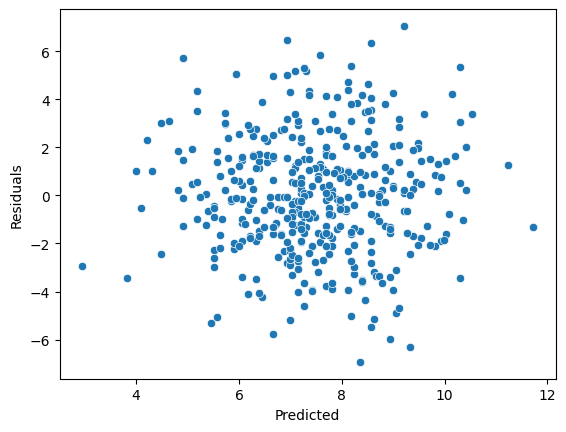

In [194]:
# fig, axs = subplots(2,1,figsize =(8 ,8))

sns.scatterplot(x=model2.predict(X2),y=model2.resid)
plt.xlabel('Predicted')
plt.ylabel('Residuals');

# infl = model2.get_influence()
# ax = axs[1]
# ax.scatter(model2.fittedvalues , infl.resid_studentized_internal)
# ax.set_xlabel('Fitted value ')
# ax.set_ylabel('Residual ')
# #ax.axhline(0, c='k', ls='--')
# ax.axhline(2, c='r', ls='--')
# ax.axhline(-2, c='r', ls='--');

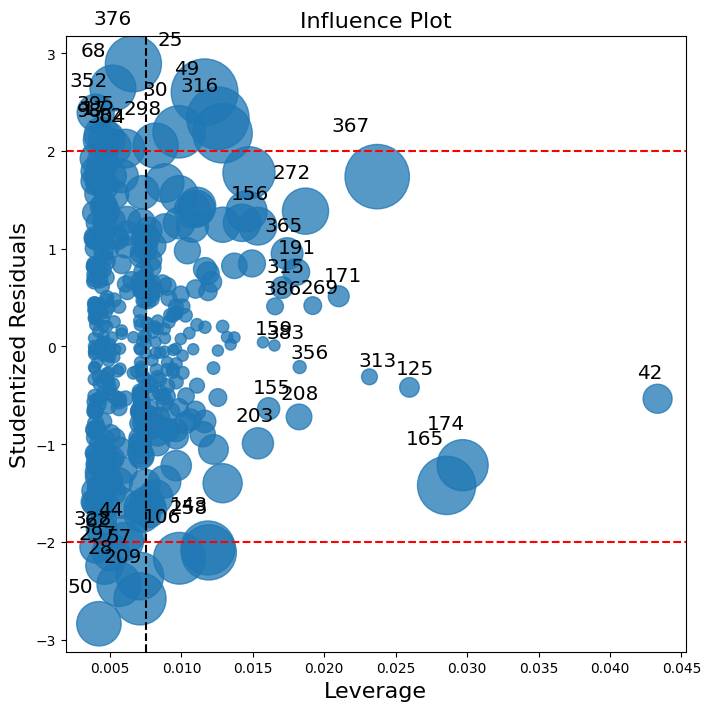

In [199]:
fig, ax = subplots(figsize=(8,8))
sm.graphics.influence_plot(model2,ax = ax)
ax.axvline((X2.shape[1])/X2.shape[0], c='k', ls='--')
ax.axhline(2, c='r', ls='--')
ax.axhline(-2, c='r', ls='--');
plt.show()

The plot indicates both points with high leverage and several outliers.